In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats as ss
import seaborn as sns
import os
import math
from data.sequencing import data_import
from data.sequencing import data_analysis

# Plot settings
plt.rcParams.update({'font.size': 15, 'svg.fonttype' : 'none', 
                     'figure.figsize' : [15,12], 'xtick.major.size' : 10, 
                     'ytick.major.size' : 10, 'lines.markersize' : 12})

In [3]:
queries = {'cat' : 'ACCGGTAAGGCACAGAAACG',
           'dna' : 'ATGTGTAAGGCACAAAAACG',
           'frame' : 'ATACGCAAGGAACAAAAACG',
           'building' : 'ATTTGCAAGGAACAAAAACG',
          'lego' : 'ACCTGTAAGGCACAGAAACG'}

bls = ['bl1', 'bl2', 'bl3', 'avg']

# Load data
q_path = '/tf/primo/data/experiments/retrieved/enrichments'
bl_path = '/tf/primo/data/experiments/baseline/enrichments'
bl_enrichments = {}
exp_enrichments = {}

for k in queries.keys():
    exp_enrichments[k] = pd.read_csv(f'{q_path}/{k}_new.csv')
    
for k in bls:
    bl_enrichments[k] = pd.read_csv(f'{bl_path}/{k}_new.csv')

In [4]:
# Filter out low read count sequences
seqs_to_rmv = [456, 119, 227]

bl_enrichments_rmv = {}
exp_enrichments_rmv = {}

for k,v in bl_enrichments.items():
    bl_enrichments_rmv[k] = v.loc[~v['seq_id'].isin(seqs_to_rmv)]
    
for k,v in exp_enrichments.items():
    exp_enrichments_rmv[k] = v.loc[~v['seq_id'].isin(seqs_to_rmv)]

# Compare enrichment to predicted activity

0.6846332153712821
0.6651208191990011
0.6239728595187642
0.742534788525861
0.7891251628170493


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

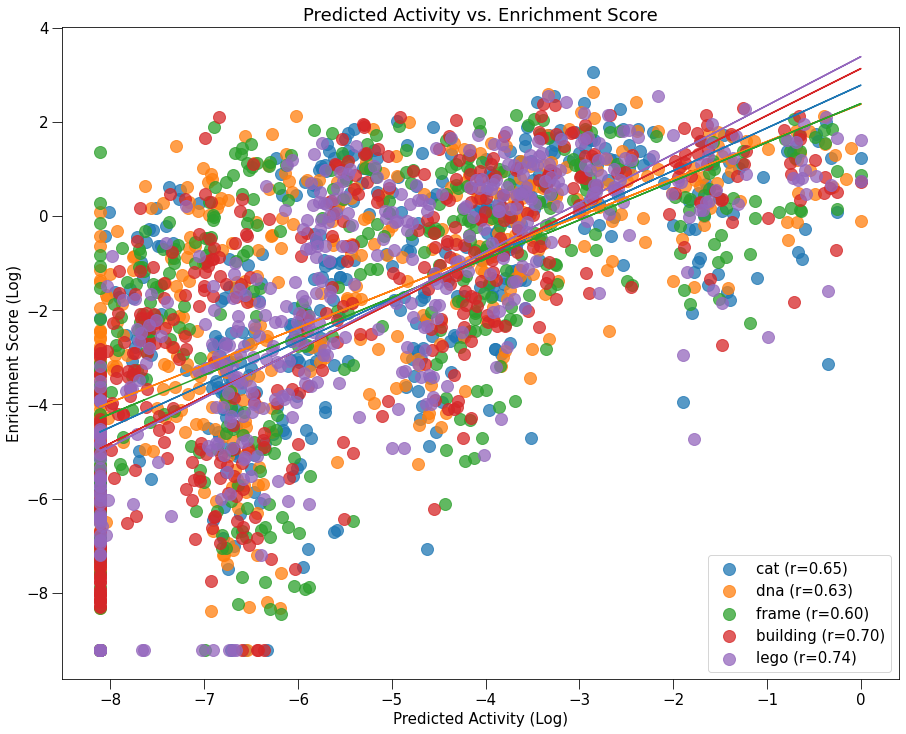

In [5]:
plt.figure()

for k, v in exp_enrichments_rmv.items():
    v['relative_enrichment_log'] = np.log(v['relative_enrichment'] + 1e-4)
    v['pred_activity_log'] = np.log(v['pred_activity'] + 1e-4)

    pearson_corr = v[['pred_activity_log', 'relative_enrichment_log']].corr(method='pearson').iloc[0, 1]
    spearman_corr = v[['pred_activity_log', 'relative_enrichment_log']].corr(method='spearman').iloc[0, 1]
    slope, intercept, r_value, p_value, std_err = ss.linregress(v['pred_activity_log'], v['relative_enrichment_log'])

    # Plotting
    plt.scatter(v['pred_activity_log'], v['relative_enrichment_log'], label=f'{k} (r={pearson_corr:.2f})', alpha=0.75)
    plt.plot(v['pred_activity_log'], intercept + slope * v['pred_activity_log'])
    print(spearman_corr)

plt.xlabel('Predicted Activity (Log)')
plt.ylabel('Enrichment Score (Log)')
plt.title('Predicted Activity vs. Enrichment Score')
plt.legend()

#plt.savefig('pred_v_es.svg', transparent=True , dpi=600, bbox_inches='tight', format='svg')

# Plot heatmap

In [6]:
df = pd.DataFrame()
num_2_seq = pd.read_csv('dfs.csv')
n2sf = num_2_seq[~num_2_seq['Unnamed: 0'].isin(seqs_to_rmv)]

df['bl1_reads'] = bl_enrichments['bl1']['reads']
df['bl2_reads'] = bl_enrichments['bl2']['reads']
for k,v in exp_enrichments_rmv.items():
    df[k+'_pred_activity'] = v['pred_activity']
    df[k+'_enr_score'] = v['relative_enrichment'].fillna(0)
    df[k+'_reads'] = v['reads']


dfm = n2sf.merge(df, left_index=True, right_index=True)

In [7]:
yd = pd.read_csv('/tf/primo/data/simulation/targets/yields_dists_new.csv').set_index("Photo_ID")
y1 = pd.read_hdf('/tf/primo/data/targets/query_target_dists_new.h5').rename(columns = {'index': 'Photo_ID'})
yd['lego'] = y1['luis_lego']
label_lkup = {'callie_janelle' :'cat',
              'webb_deep' :'webb',
              'dna_1' :'dna',
              'frame_352' :'bigfoot',
             'yuan_taipei': 'building',
              
             'FeatureSequence': 'feature_seq'}
yd = yd.rename(columns=label_lkup)
yd['Photo_ID'] = yd.index
ydk = yd[['Photo_ID','feature_seq', 'cat', 'webb', 'dna', 'building', 'bigfoot', 'lego' ]]

In [8]:
dfm

,Unnamed: 0,feature_seq,bl1_reads,bl2_reads,cat_pred_activity,cat_enr_score,cat_reads,dna_pred_activity,dna_enr_score,dna_reads,frame_pred_activity,frame_enr_score,frame_reads,building_pred_activity,building_enr_score,building_reads,lego_pred_activity,lego_enr_score,lego_reads
0,0,ACCGGTAAGGCACAAAAACG,1328.0,161.0,0.108923,5.947467,6684.0,0.146470,2.929151,11662.0,0.000764,0.006602,20.0,0.000766,0.003782,11.0,0.031931,4.953384,3256.0
1,1,ATTTGCAAGGAACAAAAACG,4415.0,692.0,0.000200,0.000943,4.0,0.004514,0.228272,3430.0,0.324764,1.375007,15721.0,1.000000,2.071799,22741.0,0.000364,0.083844,208.0
2,2,ACCTGTAAGGCACAAAAACG,1829.0,345.0,0.038301,4.513935,8780.0,0.499635,6.159567,42444.0,0.001044,0.009918,52.0,0.002614,0.087212,439.0,0.108923,3.589785,4084.0
3,3,AATTGCAAGGAACAAAAACG,1763.0,322.0,0.000200,0.000543,1.0,0.003070,0.194123,1266.0,0.220916,1.459584,7243.0,0.680235,2.314000,11024.0,0.000354,0.030648,33.0
4,4,ACCGGTAAGGTACAAAAACG,2232.0,305.0,0.014696,0.516066,1032.0,0.019763,0.109678,777.0,0.001258,0.000371,2.0,0.001262,0.000966,5.0,0.004308,0.835299,977.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,451,ATGTGCAAGGTACAAAAACG,1343.0,182.0,0.000200,0.000834,1.0,0.007015,2.331497,9898.0,0.036464,0.861524,2783.0,0.081084,2.532229,7853.0,0.000392,0.044228,31.0
452,452,TCCGGTAAGGCACAGAAACG,1857.0,204.0,1.000000,2.133828,3208.0,0.006623,0.820126,4368.0,0.000200,0.000000,0.0,0.000200,0.000000,0.0,0.526144,3.284310,2888.0
453,453,ACGGGTAAGGAACAAAAACG,2213.0,444.0,0.009114,0.168506,411.0,0.022702,0.555041,4796.0,0.011770,0.002129,14.0,0.010486,0.001901,12.0,0.002672,0.002103,3.0
454,454,GGCGGTAAGGCACAAAAACG,639.0,110.0,0.123058,2.010502,1298.0,0.241379,0.216425,495.0,0.001259,0.001149,2.0,0.001263,0.000000,0.0,0.036075,1.591572,601.0


In [9]:
cdf = pd.DataFrame()
cdf['feature_seq'] = dfm['feature_seq']
for k,v in exp_enrichments_rmv.items():
    cdf[k+'_enr_score'] = dfm[k+'_enr_score']
    cdf[k+'_reads'] = dfm[k+'_reads']
    cdf[k+'_pred_activity'] = dfm[k+'_pred_activity']

merged_df = pd.merge(cdf, ydk, on='feature_seq', how='left')

In [10]:
from sklearn.preprocessing import MinMaxScaler


# Initialize the MinMaxScaler
scaler = MinMaxScaler()

In [11]:
merged_df = merged_df.rename(columns={'bigfoot': 'frame'})

In [17]:
merged_df

,feature_seq,cat_enr_score,cat_reads,cat_pred_activity,dna_enr_score,dna_reads,dna_pred_activity,frame_enr_score,frame_reads,frame_pred_activity,...,lego_enr_score,lego_reads,lego_pred_activity,Photo_ID,cat,webb,dna,building,frame,lego
0,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,4.953384,3256.0,0.031931,000002b66c9c498e,108.944145,93.123990,98.120390,94.879684,83.317200,91.101257
1,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,4.953384,3256.0,0.031931,00006c07d2b033d1,104.143936,91.082550,101.586640,95.702710,81.477100,89.870964
2,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,4.953384,3256.0,0.031931,0000f53faa4d14c3,107.524760,93.930305,104.462006,98.305046,88.410870,88.889755
3,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,4.953384,3256.0,0.031931,0002ab17a812c0d6,105.419650,93.565080,97.230064,89.576294,84.318375,92.269531
4,ACCGGTAAGGCACAAAAACG,5.947467,6684.0,0.108923,2.929151,11662.0,0.146470,0.006602,20.0,0.000764,...,4.953384,3256.0,0.031931,000379e29dd3603a,118.903530,109.815810,113.820590,109.344600,99.868450,106.553680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741974,TCCGGTAAGGCACAGAAACG,2.133828,3208.0,1.000000,0.820126,4368.0,0.006623,0.000000,0.0,0.000200,...,3.284310,2888.0,0.526144,cd0874d33b6c5ad4,104.141310,88.570114,99.074510,89.258870,81.403740,91.403389
1741975,ACGGGTAAGGAACAAAAACG,0.168506,411.0,0.009114,0.555041,4796.0,0.022702,0.002129,14.0,0.011770,...,0.002103,3.0,0.002672,e04d8acf3931ed15,96.896935,83.612120,95.629080,76.578060,68.275450,83.294006
1741976,ACGGGTAAGGAACAAAAACG,0.168506,411.0,0.009114,0.555041,4796.0,0.022702,0.002129,14.0,0.011770,...,0.002103,3.0,0.002672,fa08b3d89f5e3242,94.386406,82.421110,92.911280,81.618530,69.168755,79.000359
1741977,GGCGGTAAGGCACAAAAACG,2.010502,1298.0,0.123058,0.216425,495.0,0.241379,0.001149,2.0,0.001259,...,1.591572,601.0,0.036075,ecd5b0ed63ef0a56,107.769730,89.354385,100.107740,91.927284,82.983320,90.893524


In [18]:
queries = {'cat' : 'ACCGGTAAGGCACAGAAACG',
           'frame' : 'ATACGCAAGGAACAAAAACG'}

In [23]:
color = ['darkblue','green']

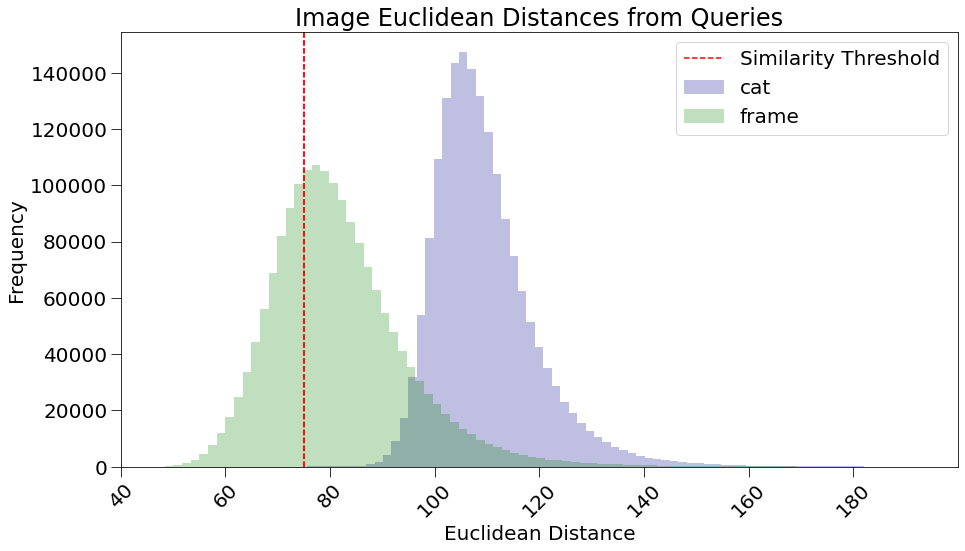

In [25]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'svg.fonttype' : 'none', 
                     'figure.figsize' : [15,8], 'xtick.major.size' : 10, 
                     'ytick.major.size' : 10})

num_bins = 200
df_sample = merged_df
for i, k in enumerate(queries.keys()):
    if k == "webb":
        continue
    #fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 8 * nrows))
    data = df_sample[k]
    data_filtered = data
    if not data_filtered.empty:
        plt.hist(data_filtered, bins=num_bins,label=k, alpha=0.25, color=color[i])
        q1, q2, q3 = np.percentile(data_filtered, [5, 50, 95])
        min_val = 40
        max_val = 200
    else:
        print(f'No data below 1 for {k}_enr_score')
plt.axvline(75, color='r', linestyle='--', label='Similarity Threshold')
plt.xticks(np.arange(min_val, max_val, step=20))
plt.xlim(min_val, max_val) 

plt.xticks(rotation=45)
plt.title('Image Euclidean Distances from Queries')
plt.xlabel('Euclidean Distance')
plt.ylabel('Frequency')
#plt.savefig(f"{k}_Ecu_hist.svg", transparent=True , dpi=600, bbox_inches='tight', format='svg')
plt.legend()
plt.axvline(75, color='r', linestyle='--', label='Similarity Threshold')
plt.savefig(f"Ecu_hist.svg", transparent=True , dpi=600, bbox_inches='tight', format='svg')

plt.show()

378.8293
373.14096
378.06735
373.8385
373.35532
369.44336


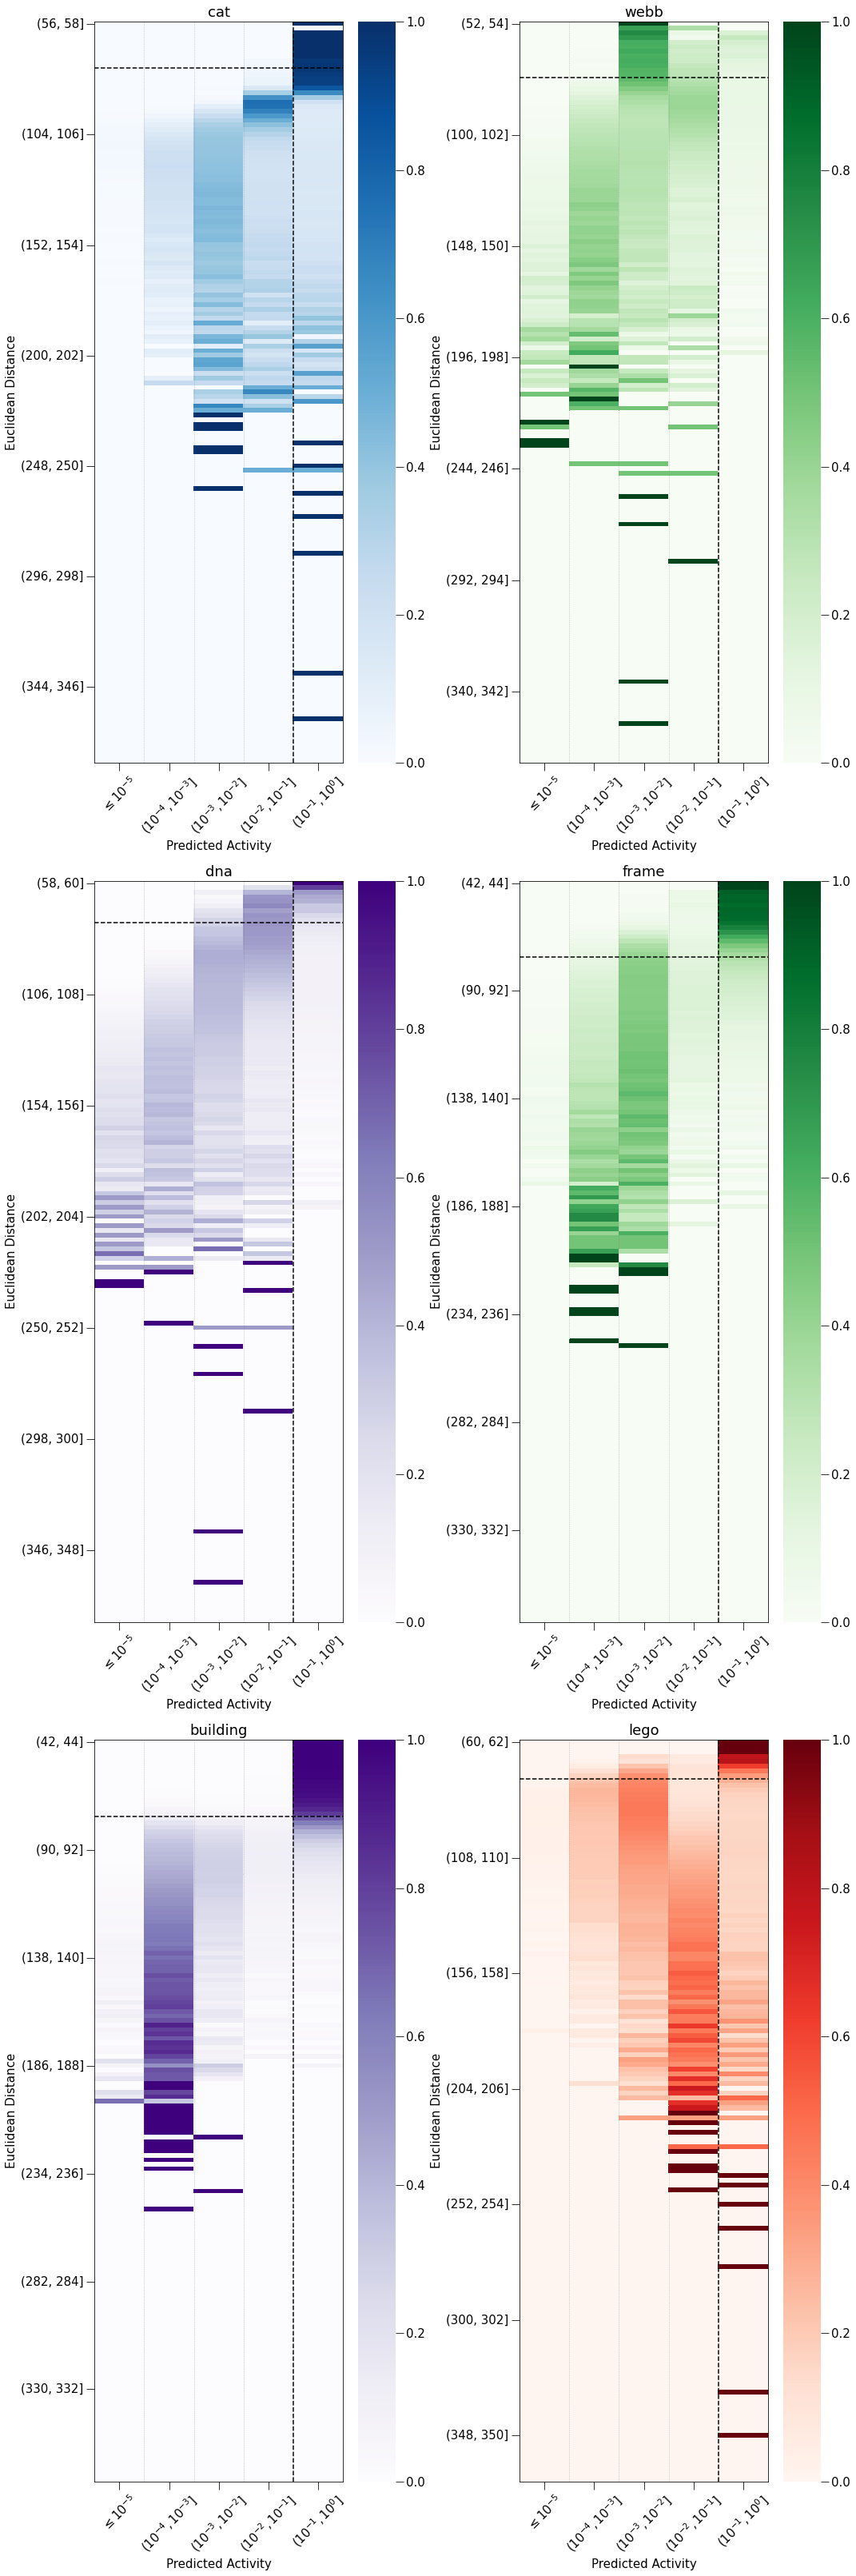

In [30]:
'''
Heatmap that shows the percent of each bin by euclid dist that fall into each bin of enrichment score

'''
nrows = math.ceil(math.sqrt(len(exp_enrichments_rmv.keys())))
ncols = math.ceil(len(exp_enrichments_rmv.keys()) / nrows)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,15 * nrows))
axs = axs.ravel()

df_sample = merged_df
colors = ['Blues', 'Greens', 'Purples', 'Greens', 'Purples', 'Reds']
xlabs = ['$\leq 10^{-5}$', '$(10^{-4}, 10^{-3}]$', '$(10^{-3}, 10^{-2}]$', '$(10^{-2}, 10^{-1}]$', '$(10^{-1}, 10^{0}]$']
for i, k in enumerate(exp_enrichments_rmv.keys()):
    step_size = 2
    min_val = (df_sample[k].min() // step_size) * step_size
    #max_distance_threshold = 200
    #bins_cat = np.arange(min_val, max_distance_threshold, step=step_size)
    bins_cat = np.arange(min_val, df_sample[k].max(), step=step_size)
    #bins_cat = np.append(bins_cat, df_sample[k].max())
    df_sample[k+'_binned'] = pd.cut(df_sample[k], bins=bins_cat)
    
    bin_position_70 = np.digitize(75, bins_cat)
    print(df_sample[k].max())
    scaler = MinMaxScaler()


    df_sample[k+'_pred_activity_norm'] = scaler.fit_transform(df_sample[[k+'_pred_activity']])
    bins_enr_score = [0, .0001,.001, .01, .1, 1]
    df_sample[k+'_pred_activity_binned'] = pd.cut(df_sample[k+'_pred_activity_norm'], bins=bins_enr_score)

    hist_data = df_sample.groupby([k+'_binned', k+'_pred_activity_binned']).size().unstack(fill_value=0)
    norm_hist_data = hist_data.div(hist_data.sum(axis=1), axis=0).fillna(0)
    y_coord_70 = bin_position_70
    sns.heatmap(norm_hist_data, cmap=colors[i], ax=axs[i])
    axs[i].set_title(f'{k}')
    axs[i].set_xlabel('Predicted Activity')
    axs[i].set_ylabel('Euclidean Distance')
    
    yticks = axs[i].get_yticks()
    xticks = axs[i].get_xticks()
    current_labels = [str(item.get_text()) for item in axs[i].get_yticklabels()]
    formatted_labels = [f"({int(float(label.split(',')[0][1:]))}, {int(float(label.split(',')[1][:-1]))}]"
                        for label in current_labels]
    axs[i].set_yticklabels(formatted_labels)
    labs = axs[i].get_yticklabels()[::6]
    axs[i].set_yticks(yticks[::6])
    axs[i].set_yticklabels(labs)
    axs[i].axhline(y=y_coord_70, color='black', linestyle='--')
    axs[i].axvline(x=xticks[3]+.5, color='black', linestyle='--')
    axs[i].tick_params(axis='both', which='major', length=10)
    axs[i].tick_params(axis='both', which='major')
    axs[i].set_xticklabels(xlabs, rotation=45)
    
    for tick in xticks:
        axs[i].axvline(x=tick+.5, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

    for _, spine in axs[i].spines.items():
        spine.set_visible(True)


plt.tight_layout()
#fig.savefig('heatmap_fig6_pred.svg', transparent=True , dpi=600, bbox_inches='tight', format='svg')

378.8293
373.8385


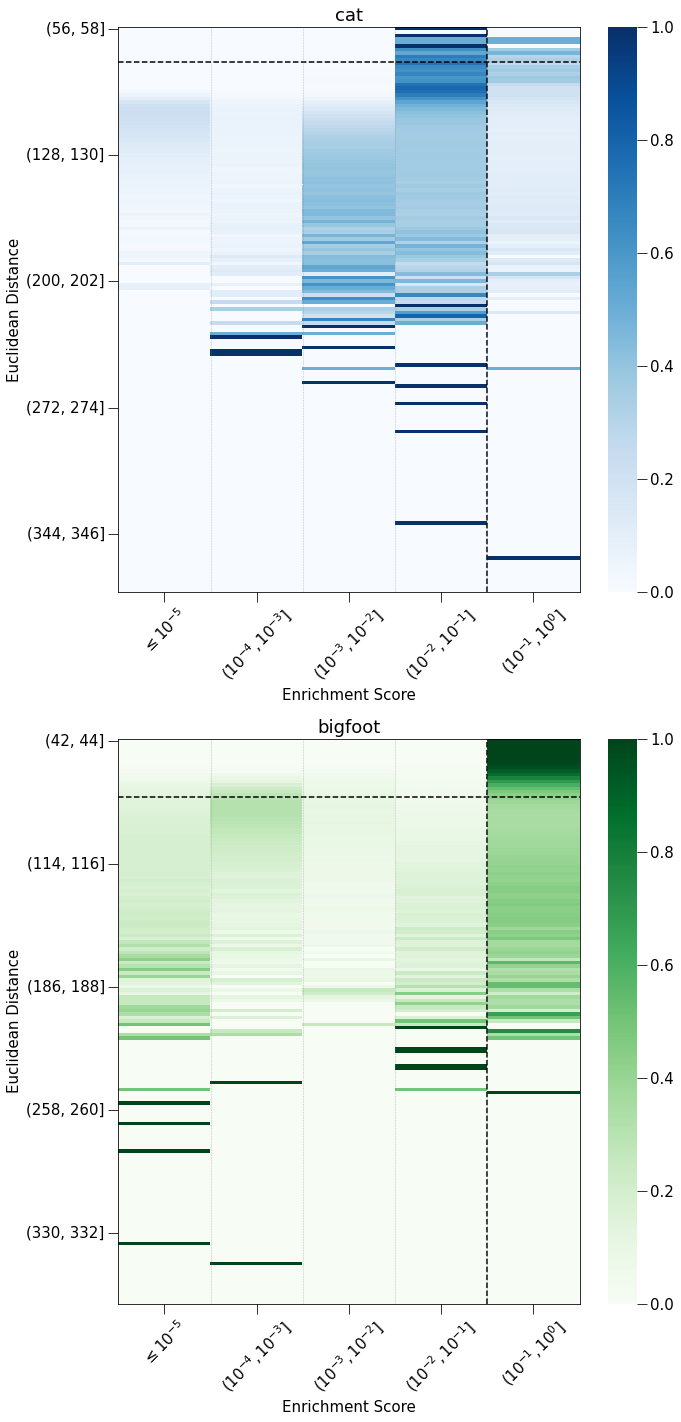

In [11]:
'''
Heatmap that shows the percent of each bin by euclid dist that fall into each bin of enrichment score

'''

nrows = math.ceil(math.sqrt(len(exp_enrichments_rmv.keys())))
ncols = math.ceil(len(exp_enrichments_rmv.keys()) / nrows)

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 10 * nrows))
axs = axs.ravel()  # Flatten the axes array

df_sample = merged_df
colors = ['Blues', 'Greens', 'Purples', 'Greens', 'Purples']
xlabs = ['$\leq 10^{-5}$', '$(10^{-4}, 10^{-3}]$', '$(10^{-3}, 10^{-2}]$', '$(10^{-2}, 10^{-1}]$', '$(10^{-1}, 10^{0}]$']
for i, k in enumerate(exp_enrichments_rmv.keys()):
    step_size = 2
    min_val = (df_sample[k].min() // step_size) * step_size
    #max_distance_threshold = 200
    #bins_cat = np.arange(min_val, max_distance_threshold, step=step_size)
    bins_cat = np.arange(min_val, df_sample[k].max(), step=step_size)
    #bins_cat = np.append(bins_cat, df_sample[k].max())
    df_sample[k+'_binned'] = pd.cut(df_sample[k], bins=bins_cat)

    bin_position_70 = np.digitize(75, bins_cat)
    print(df_sample[k].max())
    scaler = MinMaxScaler()
    df_sample[k+'_enr_score_norm'] = scaler.fit_transform(df_sample[[k+'_enr_score']])
    bins_enr_score = [0,.0001, .001, .01, .1, 1]
    df_sample[k+'_enr_score_binned'] = pd.cut(df_sample[k+'_enr_score_norm'], bins=bins_enr_score)
    
    hist_data = df_sample.groupby([k+'_binned', k+'_enr_score_binned']).size().unstack(fill_value=0)
    norm_hist_data = hist_data.div(hist_data.sum(axis=1), axis=0).fillna(0)
    y_coord_70 = bin_position_70
    sns.heatmap(norm_hist_data, cmap=colors[i], ax=axs[i])
    axs[i].set_title(f'{k}')
    axs[i].set_xlabel('Enrichment Score')
    axs[i].set_ylabel('Euclidean Distance')
    xticks = axs[i].get_xticks()
    yticks = axs[i].get_yticks()
    current_labels = [str(item.get_text()) for item in axs[i].get_yticklabels()]
    formatted_labels = [f"({int(float(label.split(',')[0][1:]))}, {int(float(label.split(',')[1][:-1]))}]"
                        for label in current_labels]
    axs[i].set_yticklabels(formatted_labels)
    labs = axs[i].get_yticklabels()[::6]
    axs[i].set_yticks(yticks[::6])
    axs[i].set_yticklabels(labs)
    axs[i].axhline(y=y_coord_70, color='black', linestyle='--')
    axs[i].axvline(x=xticks[3]+.5, color='black', linestyle='--')
    axs[i].tick_params(axis='both', which='major', length=10)
    axs[i].tick_params(axis='both', which='major')
    axs[i].set_xticklabels(xlabs, rotation=45)
    for tick in xticks:
        axs[i].axvline(x=tick+.5, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)


    # Add a border around the plot
    for _, spine in axs[i].spines.items():
        spine.set_visible(True)


plt.tight_layout()
#fig.savefig('heatmap_fig6.svg', transparent=True , dpi=600, bbox_inches='tight', format='svg')

In [12]:
# Import 3rd baseline as 'random' comparison
bl_comp = pd.read_csv(q_path + '/bl3.csv')
bl_comp = bl_comp[~bl_comp['seq_id'].isin(seqs_to_rmv)]
bl_comp['cat_pred_activity'] = dfm['cat_pred_activity']
bl_comp['bigfoot_pred_activity'] = dfm['bigfoot_pred_activity']
# Ugly, but in the sake of time good enough
bl_comp['cat_enr_score'] = bl_comp['relative_enrichment']
bl_comp['bigfoot_enr_score'] = bl_comp['relative_enrichment']

0.6852179210293176
0.030503935271100586
0.6253435882299937
-0.01283753673496654


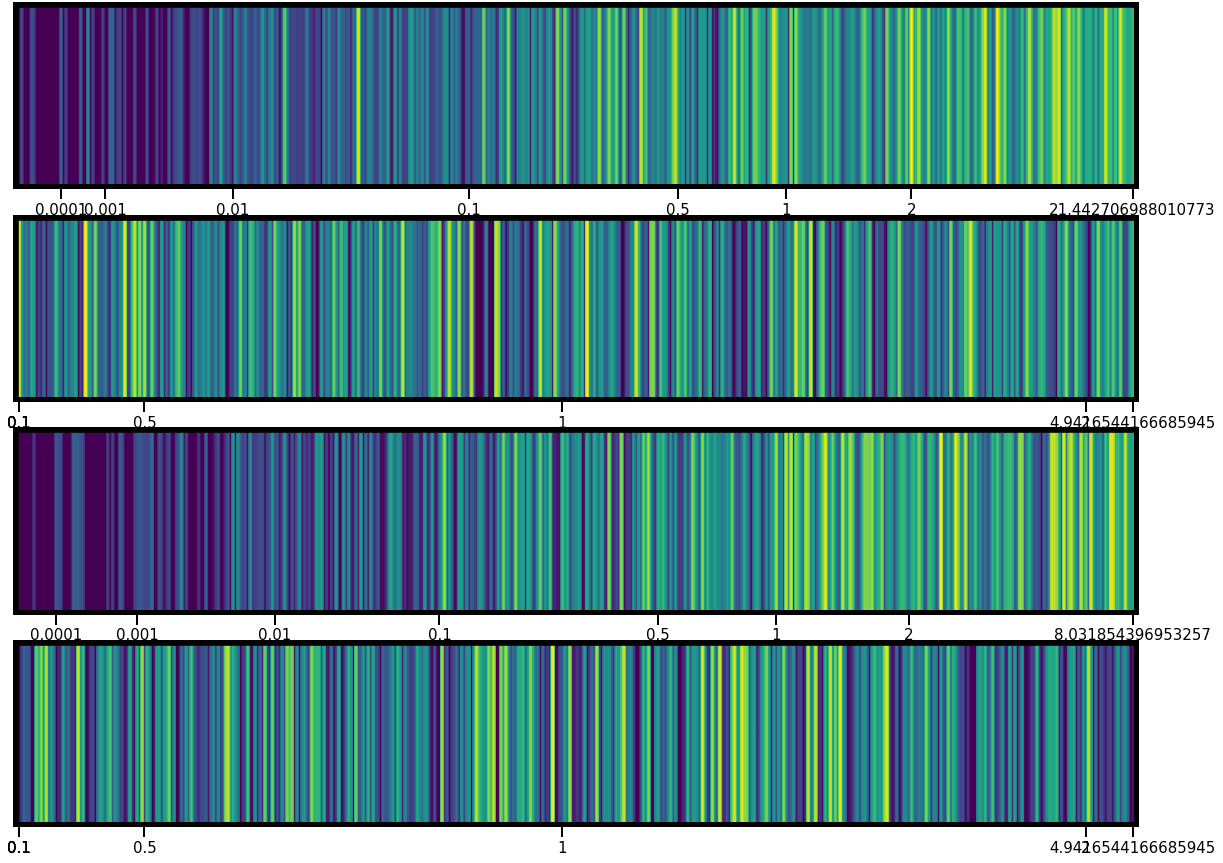

In [13]:
fig, axs = plt.subplots(4, 1, figsize=(20, 15))


def display_colormap(cmap, data, ax, k):
    gradient = np.vstack((data[k+'_pred_activity'], data[k+'_pred_activity']))
    ax.imshow(gradient, aspect='auto', cmap=cmap, norm=matplotlib.colors.LogNorm())
    ax.set_axis_on()
    x_ticks = [0.0001, 0.001, 0.01, 0.1, .5, 1, 2]
    x_ticks.append(data[k+'_enr_score'].max())
    tick_indices = [len(data[data[k+'_enr_score'] < x]) for x in x_ticks]
    
    ax.set_xticks(tick_indices)
    ax.tick_params(axis='x', length=15, width=2)
    ax.set_xticklabels(x_ticks)
    ax.set_yticks([])

    ax.patch.set_edgecolor('black') 
    ax.patch.set_linewidth(10)
    
    spearman_corr = data[[k+'_enr_score', k+'_pred_activity']].corr(method='spearman').iloc[0, 1]
    print(spearman_corr)

tmp = dfm.sort_values(by='cat_enr_score')
ax = axs[0]
display_colormap('viridis', tmp, ax, 'cat')

ax = axs[1]
tmp = bl_comp.sort_values(by='relative_enrichment')
display_colormap('viridis', tmp, ax, 'cat')

tmp = dfm.sort_values(by='bigfoot_enr_score')
ax = axs[2]
display_colormap('viridis', tmp, ax, 'bigfoot')

ax = axs[3]
tmp = bl_comp.sort_values(by='relative_enrichment')
display_colormap('viridis', tmp, ax, 'bigfoot')


#plt.savefig(f"esvpred_bl.svg", transparent=True , dpi=600, bbox_inches='tight', format='svg')

In [31]:
queries

{'cat': 'ACCGGTAAGGCACAGAAACG',
 'webb': 'ATCTGTAAGGCACAAAAACG',
 'dna': 'ATGTGTAAGGCACAAAAACG',
 'frame': 'ATACGCAAGGAACAAAAACG',
 'building': 'ATTTGCAAGGAACAAAAACG',
 'lego': 'ACCTGTAAGGCACAGAAACG'}

In [32]:
# Split categories for totaling
for k in queries.keys():
    merged_df[k+'_pos_or_neg'] = np.where(merged_df[k] > 75, 0, 1)
    merged_df[k+'_sim_pos_or_neg'] = np.where(merged_df[k+'_pred_activity'] <= .1, 0, 1)
    merged_df[k+'_exp_pos_or_neg'] = np.where(merged_df[k+'_enr_score'] <= 1, 0, 1)

In [33]:
def category_totals(y_true, y_pred):
    true_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 1)
    false_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == 0 and pred == 1)
    false_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 0)
    true_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 0)
    
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    totalpos = sum(1 for true in y_true if true == 1)
    totalneg = sum(1 for true in y_true if true == 0)
    return [true_positive/totalpos, false_negative/totalpos, true_negative/totalneg, false_positive/totalneg]
    #return f1



In [36]:
def category_totals(y_true, y_pred):
    true_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 1)
    false_positive = sum(1 for true, pred in zip(y_true, y_pred) if true == 0 and pred == 1)
    false_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == 1 and pred == 0)
    true_negative = sum(1 for true, pred in zip(y_true, y_pred) if true == pred == 0)
    
    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive else 0
    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    totalpos = sum(1 for true in y_true if true == 1)
    totalneg = sum(1 for true in y_true if true == 0)
    return [true_positive, false_negative, true_negative, false_positive]
    #return f1